# Efficient hyperparameter search with GridSearchCV and optuna

Authors:
- [Alexandre Gramfort](https://alexandre.gramfort.net/)
- [Thomas Moreau](https://tommoral.github.io/about.html)
- [Pedro L. C. Rodrigues](https://plcrodrigues.github.io/)

adapted from the work of Olivier Grisel and Andreas Mueller.

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

Most models have hyperparameters that influence the complexity of the functions that they can learn. Think the depth of a decision tree.

<img src="figures/overfitting_underfitting_cartoon.svg" width="60%">

## Hyperparameters, Over-fitting, and Under-fitting

Unfortunately, there is no general rule on how to find the sweet spot, and so machine learning practitioners have to find the best trade-off of model-complexity and generalization by trying several hyperparameter settings. Hyperparameters are the internal knobs or tuning parameters of a machine learning algorithm (in contrast to model parameters that the algorithm learns from the training data -- for example, the weight coefficients of a linear regression model); the depth of a decision tree or the number of trees in a gradient boosting are such hyperparameters.

Most commonly this "hyperparameter tuning" is done using a brute force search, for example over multiple values of ``max_depth``:

In [3]:
import pandas as pd

from sklearn.model_selection import cross_val_score, KFold
from sklearn.tree import DecisionTreeRegressor

print('Loading data...')
# load or create your dataset
df_train = pd.read_csv('datasets/regression.train', header=None, sep='\t')
df_test = pd.read_csv('datasets/regression.test', header=None, sep='\t')

df = pd.concat([df_train, df_test], axis=0)
y = df[0].values
X = df.drop(0, axis=1).values

cv = KFold(shuffle=True, n_splits=5, random_state=42)

reg = DecisionTreeRegressor()

# for each parameter setting do cross-validation:
for max_depth in [1, 3, 5, 10, 20]:
    reg.set_params(max_depth=max_depth)
    scores = cross_val_score(reg, X, y, cv=cv, scoring="r2")
    print(f"max_depth: {max_depth}, average score: {np.mean(scores)}")

Loading data...
max_depth: 1, average score: 0.041434776747087156
max_depth: 3, average score: 0.0998374290737992
max_depth: 5, average score: 0.11641424657048097
max_depth: 10, average score: -0.117509902022553
max_depth: 20, average score: -0.5523504424753325


There is a function in scikit-learn, called ``validation_plot`` to reproduce the cartoon figure above. It plots one parameter, such as the number of neighbors, against training and validation error (using cross-validation):

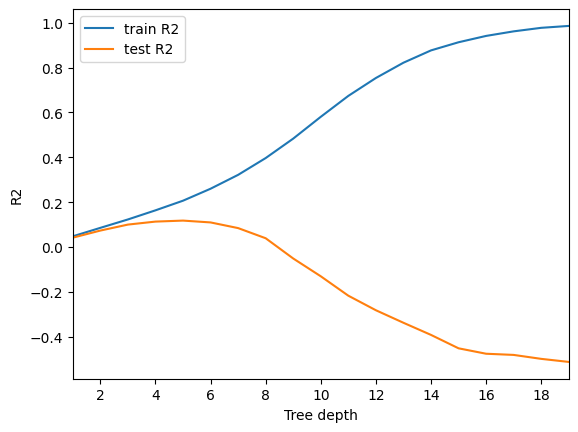

In [4]:
from sklearn.model_selection import validation_curve

max_depth = np.arange(1, 20)
    
train_scores, test_scores = validation_curve(
    reg, X, y, param_name="max_depth",
    param_range=max_depth, cv=cv,
    scoring="r2"
)
plt.plot(max_depth, train_scores.mean(axis=1), label="train R2")
plt.plot(max_depth, test_scores.mean(axis=1), label="test R2")
plt.ylabel('R2')
plt.xlabel('Tree depth')
plt.xlim([1, max(max_depth)])
plt.legend(loc="best");

One way to automatize hyperparameter search is to use a built-in class in scikit-learn: ``GridSearchCV``, which takes a dictionary describing the parameters to sweep and which model to train. This grid of parameters is defined as a dictionary, where the keys are the parameters and the values are the settings to be tested.

To inspect the training score on different folds, we can set parameter ``return_train_score`` to ``True``.

In [6]:
from sklearn.model_selection import GridSearchCV
max_depth = [1, 2, 3, 4, 5, 6, 7]
param_grid = {'max_depth': max_depth}

grid = GridSearchCV(DecisionTreeRegressor(), param_grid=param_grid,
                    cv=cv, verbose=3,
                    return_train_score=True, n_jobs=-1)

One of the great things about `GridSearchCV` is that it is a **meta-estimator**. It takes an estimator like `DecisionTreeRegressor` above, and creates a new estimator that behaves exactly the same - in this case, like a regressor.
So we can call ``fit`` on it, to train it:

In [7]:
grid.fit(X, y)

Fitting 5 folds for each of 7 candidates, totalling 35 fits


,estimator,DecisionTreeRegressor()
,param_grid,"{'max_depth': [1, 2, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,criterion,'squared_error'


What ``fit`` does is a bit more involved then what we did above. First, it runs the same loop with cross-validation, to find the best parameter combination.
Once it has the best combination, it runs fit again on all data passed to fit (without cross-validation), to build a single new model using the best parameter setting.

> [PLCR] In other words, is does a sub-cross validation using smaller splits for X

Then, as with all models, we can use ``predict`` or ``score``:


In [8]:
grid.predict(X)

array([0.8697479 , 0.8697479 , 0.68272425, ..., 0.61587302, 0.28220859,
       0.51453488], shape=(7500,))

You can inspect the best parameters found by ``GridSearchCV`` in the ``best_params_`` attribute, and the best score in the ``best_score_`` attribute:

In [9]:
print(grid.best_score_)

0.11694942185822688


In [10]:
print(grid.best_params_)

{'max_depth': 5}


We can investigate the performance and much more for each set of parameter values by accessing the `cv_results_` attributes, which is a dictionary where each key is a string and each value is an array. It can therefore be used to make a pandas DataFrame.

In [11]:
type(grid.cv_results_)

dict

In [12]:
print(grid.cv_results_.keys())

dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_max_depth', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score', 'mean_test_score', 'std_test_score', 'rank_test_score', 'split0_train_score', 'split1_train_score', 'split2_train_score', 'split3_train_score', 'split4_train_score', 'mean_train_score', 'std_train_score'])


In [13]:
import pandas as pd

cv_results = pd.DataFrame(grid.cv_results_)
cv_results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.013886,0.002312,0.000862,0.000464,1,{'max_depth': 1},0.037408,0.059269,0.022200,0.041881,...,0.041435,0.012077,7,0.048678,0.042985,0.052221,0.047135,0.046596,0.047523,0.003000
1,0.022948,0.002185,0.000761,0.000372,2,{'max_depth': 2},0.067777,0.108785,0.055390,0.052709,...,0.073139,0.020465,6,0.082155,0.083899,0.087353,0.082700,0.090348,0.085291,0.003108
2,0.032756,0.004792,0.000893,0.000717,3,{'max_depth': 3},0.091159,0.134029,0.097577,0.056400,...,0.099837,0.026622,4,0.122633,0.120839,0.131610,0.114817,0.123688,0.122717,0.005403
3,0.041443,0.002542,0.000440,0.000173,4,{'max_depth': 4},0.095534,0.154370,0.107212,0.065095,...,0.113183,0.032519,2,0.162374,0.164971,0.164933,0.160026,0.164627,0.163386,0.001937
4,0.051666,0.003843,0.000518,0.000160,5,{'max_depth': 5},0.113616,0.144012,0.087920,0.099055,...,0.116949,0.022111,1,0.208677,0.206199,0.206271,0.201842,0.208971,0.206392,0.002555


In [14]:
cv_results_tiny = cv_results[['param_max_depth', 'mean_test_score']]
cv_results_tiny.sort_values(by='mean_test_score', ascending=False).head()

,param_max_depth,mean_test_score
4,5,0.116949
3,4,0.113183
5,6,0.110487
2,3,0.099837
6,7,0.082289


There is a problem with using this score for evaluation, however. You might be making what is called a **multiple hypothesis testing error**: if you try several parameter settings, some of them will work better just by chance, and the score that you have obtained might not reflect how your model would perform on new unseen data.
Therefore, it is good to split off a separate test-set before performing grid-search. This pattern can be seen as a training-validation-test split, and is common in machine learning:

<img src="figures/grid_search_cross_validation.svg" width="70%">

We can do this very easily by splitting of some test data using ``train_test_split``, training ``GridSearchCV`` on the training set, and applying the ``score`` method to the test set:

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

param_grid = {'max_depth': max_depth}
cv = KFold(n_splits=10, shuffle=True)

grid = GridSearchCV(DecisionTreeRegressor(), param_grid=param_grid, cv=cv)

grid.fit(X_train, y_train)
grid.score(X_test, y_test)

0.11152232083900504

We can also look at the parameters that were selected:

In [16]:
grid.best_params_

{'max_depth': 4}

[CV 5/5] END ...max_depth=2;, score=(train=0.090, test=0.081) total time=   0.0s
[CV 2/5] END ...max_depth=6;, score=(train=0.264, test=0.147) total time=   0.1s
[CV 2/5] END ...max_depth=2;, score=(train=0.084, test=0.109) total time=   0.0s
[CV 1/5] END ...max_depth=3;, score=(train=0.123, test=0.091) total time=   0.0s
[CV 4/5] END ...max_depth=3;, score=(train=0.115, test=0.056) total time=   0.0s
[CV 4/5] END ...max_depth=4;, score=(train=0.160, test=0.065) total time=   0.0s
[CV 4/5] END ...max_depth=6;, score=(train=0.252, test=0.099) total time=   0.1s
[CV 1/5] END ...max_depth=2;, score=(train=0.082, test=0.068) total time=   0.0s
[CV 5/5] END ...max_depth=3;, score=(train=0.124, test=0.120) total time=   0.0s
[CV 5/5] END ...max_depth=4;, score=(train=0.165, test=0.144) total time=   0.0s
[CV 3/5] END ...max_depth=6;, score=(train=0.264, test=0.080) total time=   0.1s
[CV 4/5] END ...max_depth=1;, score=(train=0.047, test=0.042) total time=   0.0s
[CV 1/5] END ...max_depth=6;

Some practitioners go for an easier scheme, splitting the data simply into three parts, training, validation and testing. This is a possible alternative if your training set is very large, or it is infeasible to train many models using cross-validation because training a model takes very long.
You can do this with scikit-learn for example by splitting of a test-set and then applying GridSearchCV with ShuffleSplit cross-validation with a single iteration:

<img src="figures/train_validation_test2.svg" width="60%">

In [17]:
from sklearn.model_selection import train_test_split, ShuffleSplit

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

param_grid = {'max_depth': max_depth}
single_split_cv = ShuffleSplit(n_splits=1, test_size=0.2)

grid = GridSearchCV(DecisionTreeRegressor(), param_grid=param_grid, cv=single_split_cv, verbose=3)

grid.fit(X_train, y_train)
grid.score(X_test, y_test)

Fitting 1 folds for each of 7 candidates, totalling 7 fits
[CV 1/1] END .......................max_depth=1;, score=0.036 total time=   0.0s
[CV 1/1] END .......................max_depth=2;, score=0.079 total time=   0.0s
[CV 1/1] END .......................max_depth=3;, score=0.104 total time=   0.0s
[CV 1/1] END .......................max_depth=4;, score=0.128 total time=   0.0s
[CV 1/1] END .......................max_depth=5;, score=0.140 total time=   0.0s
[CV 1/1] END .......................max_depth=6;, score=0.135 total time=   0.0s
[CV 1/1] END .......................max_depth=7;, score=0.070 total time=   0.0s


0.1111365917931505

This is much faster, but it might result in worse hyperparameters and therefore worse results as the error estimate on left-out data will have much more variance. In other words you're more likely to be unlucky!

<div class="alert alert-success">
    <b>EXERCISE</b>:
     <ul>
      <li>
      Apply grid-search to find the best learning_rate and number of trees in a HistGradientBoostingRegressor.
      </li>
    </ul>
</div>

Solution is in: `solutions/03-gbdt_grid_search_cv.py`

In [22]:
from sklearn.model_selection import train_test_split, ShuffleSplit
from sklearn.ensemble import HistGradientBoostingRegressor

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

param_grid = {'learning_rate': [0.05, 0.075, 0.1, 0.125, 0.15]}

reg = HistGradientBoostingRegressor()

single_split_cv = ShuffleSplit(n_splits=1, test_size=0.2)

grid = GridSearchCV(reg, param_grid=param_grid, cv=single_split_cv, verbose=3)

grid.fit(X_train, y_train)
print(grid.score(X_test, y_test))


Fitting 1 folds for each of 5 candidates, totalling 5 fits
[CV 1/1] END ................learning_rate=0.05;, score=0.223 total time=   0.4s
[CV 1/1] END ...............learning_rate=0.075;, score=0.214 total time=   0.3s
[CV 1/1] END .................learning_rate=0.1;, score=0.215 total time=   0.3s
[CV 1/1] END ...............learning_rate=0.125;, score=0.184 total time=   0.3s
[CV 1/1] END ................learning_rate=0.15;, score=0.175 total time=   0.4s
0.22342480493503336


In [23]:
grid.best_params_

{'learning_rate': 0.05}

Suppose now that we wanted to tune the hyperparameters of a regressor coming out from `skrub` such as in:

In [24]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
est = make_pipeline(StandardScaler(), HistGradientBoostingRegressor())
est

,steps,"[('standardscaler', ...), ('histgradientboostingregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,loss,'squared_error'
,quantile,None
,learning_rate,0.1
,max_iter,100


To access the `learning_rate` from the regressor in this pipeline, we need help from `get_params` attribute

In [25]:
est.get_params()

{'memory': None,
 'steps': [('standardscaler', StandardScaler()),
  ('histgradientboostingregressor', HistGradientBoostingRegressor())],
 'transform_input': None,
 'verbose': False,
 'standardscaler': StandardScaler(),
 'histgradientboostingregressor': HistGradientBoostingRegressor(),
 'standardscaler__copy': True,
 'standardscaler__with_mean': True,
 'standardscaler__with_std': True,
 'histgradientboostingregressor__categorical_features': 'from_dtype',
 'histgradientboostingregressor__early_stopping': 'auto',
 'histgradientboostingregressor__interaction_cst': None,
 'histgradientboostingregressor__l2_regularization': 0.0,
 'histgradientboostingregressor__learning_rate': 0.1,
 'histgradientboostingregressor__loss': 'squared_error',
 'histgradientboostingregressor__max_bins': 255,
 'histgradientboostingregressor__max_depth': None,
 'histgradientboostingregressor__max_features': 1.0,
 'histgradientboostingregressor__max_iter': 100,
 'histgradientboostingregressor__max_leaf_nodes': 31,
 '

In [26]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler
import pandas as pd

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

param_grid = {'histgradientboostingregressor__learning_rate': [0.1, 0.5, 1.0]}
single_split_cv = ShuffleSplit(n_splits=1, test_size=0.2)

grid = GridSearchCV(est, param_grid=param_grid, cv=single_split_cv, verbose=3)

grid.fit(X_train, y_train)
grid.score(X_test, y_test)

Fitting 1 folds for each of 3 candidates, totalling 3 fits
[CV 1/1] END histgradientboostingregressor__learning_rate=0.1;, score=0.240 total time=   0.5s
[CV 1/1] END histgradientboostingregressor__learning_rate=0.5;, score=0.057 total time=   0.4s
[CV 1/1] END histgradientboostingregressor__learning_rate=1.0;, score=-0.407 total time=   0.4s


0.20301129544183005

**What did Grid Search actually do?**

At this point, it is useful to pause and reflect:

- How many models were trained in total?
- How many of them performed clearly worse than the best one?
- Did the grid resolution match the sensitivity of the model?

Grid search does not *learn* from previous evaluations.
Each configuration is tested independently, even if previous results already suggest it is unlikely to perform well.

This observation motivates a more adaptive strategy.

## Guided hyper-optimization

So far we did hyper-optimization by giving a list of values to be tried. 

We were able to automatically generated these values (randomly or not) by using `RandomSearchCV` or `GridSearchCV`.

We can expect to do better by trying certain parameters which "are more likely" to optimize our problem given previous parameters.

We will use `optuna` to do so.


URL : https://pypi.org/project/optuna/

See video : https://www.youtube.com/watch?v=J_aymk4YXhg

In [27]:
!pip install optuna

In [28]:
import optuna

def objective(trial):
    x = trial.suggest_float('x', -10, 10)
    return (x-2)**2

study = optuna.create_study()
study.optimize(objective, n_trials=100)

print(study.best_params)

[I 2025-12-19 11:27:45,481] A new study created in memory with name: no-name-d348feff-428b-4822-a3ed-138636d13708
[I 2025-12-19 11:27:45,482] Trial 0 finished with value: 2.5459182792841375 and parameters: {'x': 3.5955933940964213}. Best is trial 0 with value: 2.5459182792841375.
[I 2025-12-19 11:27:45,483] Trial 1 finished with value: 35.76472713919208 and parameters: {'x': 7.980361789991646}. Best is trial 0 with value: 2.5459182792841375.
[I 2025-12-19 11:27:45,483] Trial 2 finished with value: 14.013838895068357 and parameters: {'x': 5.743506230136175}. Best is trial 0 with value: 2.5459182792841375.
[I 2025-12-19 11:27:45,483] Trial 3 finished with value: 43.18404673950532 and parameters: {'x': -4.5714569723544045}. Best is trial 0 with value: 2.5459182792841375.
[I 2025-12-19 11:27:45,483] Trial 4 finished with value: 0.10823449080744182 and parameters: {'x': 1.671009892538633}. Best is trial 4 with value: 0.10823449080744182.
[I 2025-12-19 11:27:45,483] Trial 5 finished with val

{'x': 1.9946352524676578}


In [30]:
import optuna
from optuna import samplers
from sklearn.svm import SVR
from functools import partial

def objective(trial, df_train, df_test):
    
    cat = trial.suggest_categorical("est", ["boost", "svr"])
    
    if cat == 'boost':
    
        max_depth = trial.suggest_int('max_depth', 2, 32)
        learning_rate = trial.suggest_float('learning_rate', 10**-5, 10**0, log=True)
        l2_regularization = trial.suggest_float('l2_regularization', 10**-5, 10**0, log=True)
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 100)

        reg = HistGradientBoostingRegressor(
            max_depth=max_depth,
            learning_rate=learning_rate,
            l2_regularization=l2_regularization, 
            min_samples_leaf=min_samples_leaf,
            random_state=42,
        )

    elif cat == 'svr':

        C = trial.suggest_float('C', 1e-3, 1e1, log=True)
        reg = SVR(C=C)
        
    return np.mean(cross_val_score(reg, X, y, cv=5, n_jobs=-1, scoring="r2"))

df_train = pd.read_csv('datasets/regression.train', header=None, sep='\t')
df_test = pd.read_csv('datasets/regression.test', header=None, sep='\t')
df = pd.concat([df_train, df_test], axis=0)
y = df[0].values
X = df.drop(0, axis=1).values

sampler = samplers.TPESampler(seed=10)
study = optuna.create_study(sampler=sampler, direction='maximize')
optuna.logging.disable_default_handler()  # limit verbosity
study.optimize(partial(objective, df_train=df_train, df_test=df_test), n_trials=10)

# Show best result
print(study.best_trial.params)
print(study.best_trial.value)

{'est': 'boost', 'max_depth': 21, 'learning_rate': 0.05546505049361993, 'l2_regularization': 0.003108386839260201, 'min_samples_leaf': 23}
0.23156911636239313


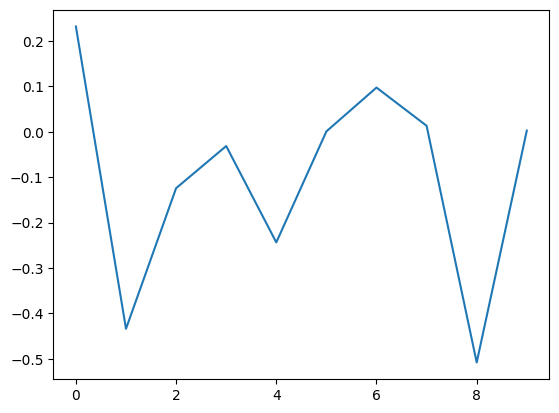

In [31]:
values = [t.value for t in study.trials]
plt.plot(values)

Text(0, 0.5, 'R2')

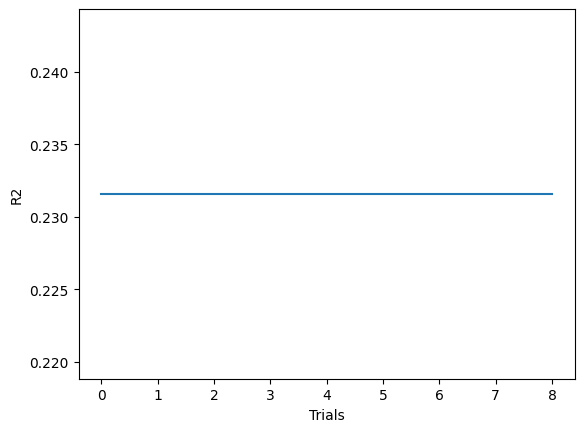

In [32]:
values = [t.value for t in study.trials]
values = [np.max(values[:k]) for k in range(1, len(values))]
plt.plot(values)
plt.xlabel('Trials')
plt.ylabel('R2')

In [33]:
reg = HistGradientBoostingRegressor(random_state=42)
params = study.best_trial.params
params.pop('est')
reg.set_params(**params)
reg.fit(X_train, y_train)
reg.score(X_test, y_test)

0.2207645866304102

To learn more please have a look at the doc of optuna. In particular:

https://optuna.readthedocs.io/en/stable/reference/generated/optuna.study.Study.html#optuna.study.Study.optimize